# Periódicos e congressos da base IEEE indexados na Scopus

**Pergunta:** dos periódicos e congressos distintos onde recuperei artigos na IEEE Xplore (`base_ieee_consolidada.csv`), qual percentual é, em si, uma fonte indexada na Scopus? Cada fonte conta uma única vez, não importa quantos artigos ela tenha na base — se "IEEE Teste" aparece em 50 registros e está na Scopus, conta como 1 (indexada), não como 50.

**Critério de verdade:** a lista oficial de fontes da Scopus (`ext_list_Jul_2026.xlsx`, Elsevier, jul/2026), casando por **ISSN/EISSN** (periódicos) e **ISBN** (anais de congresso, por volume).

In [1]:
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd
from rapidfuzz import fuzz, process
from unidecode import unidecode

pd.set_option("display.max_colwidth", 100)
plt.rcParams["figure.dpi"] = 110

## 1. Carregamento das bases

In [2]:
arquivo_ieee = "../ajustes_BD/SCOPUS_IEEE_WOS/base_ieee_consolidada.csv"
arquivo_scopus_sources = "ext_list_Jul_2026.xlsx"

df_ieee = pd.read_csv(arquivo_ieee, encoding="utf-8")
df_jour = pd.read_excel(arquivo_scopus_sources, sheet_name="Scopus Sources Jul. 2026", engine="openpyxl")
df_serial = pd.read_excel(arquivo_scopus_sources, sheet_name="Serial Conf. Proc. with Profile", engine="openpyxl")
df_conf = pd.read_excel(arquivo_scopus_sources, sheet_name="All Conf. Proceedings Jun. 2026", engine="openpyxl")

print(f"IEEE:                         {len(df_ieee):>7} registros")
print(f"Scopus - periódicos:          {len(df_jour):>7} fontes")
print(f"Scopus - séries de congresso: {len(df_serial):>7} fontes")
print(f"Scopus - anais de congresso:  {len(df_conf):>7} volumes indexados")

IEEE:                            1646 registros
Scopus - periódicos:            48888 fontes
Scopus - séries de congresso:    1031 fontes
Scopus - anais de congresso:   180588 volumes indexados


## 2. Classificação dos documentos IEEE por tipo de fonte

- **Periódicos** (`IEEE Journals`, `IEEE Magazines`, `IEEE Early Access Articles` e periódicos de parceiros): checados contra a aba `Scopus Sources` (ISSN/EISSN).
- **Conferências** (`IEEE Conferences`, `IET Conferences`): checadas contra `All Conf. Proceedings` (ISBN do volume) e `Serial Conf. Proc. with Profile` (ISSN da série).
- **Livros, capítulos e normas**: a Scopus não os trata como periódico nem como anais de congresso — ficam fora da pergunta e são só listados à parte (seção 9).

In [3]:
PERIODICOS = {
    "IEEE Journals", "IEEE Magazines", "IEEE Early Access Articles",
    "River Publishers Journals", "IBM Journals", "OUP Journals",
    "SGEPRI Journals", "TUP Journals",
}
CONFERENCIAS = {"IEEE Conferences", "IET Conferences"}


def classifica(doc_id):
    if doc_id in PERIODICOS:
        return "periodico"
    if doc_id in CONFERENCIAS:
        return "conferencia"
    return "livro_norma"


df_ieee["tipo_fonte"] = df_ieee["Document Identifier"].apply(classifica)
df_ieee["tipo_fonte"].value_counts()

tipo_fonte
conferencia    1360
periodico       205
livro_norma      81
Name: count, dtype: int64

## 3. Normalização de ISSN, ISBN e título

- **ISSN**: remove hífen/pontuação, mantém dígitos e o `X` de checagem, completa com zeros à esquerda até 8 caracteres.
- **ISBN**: remove hífen/pontuação; a coluna `ISBN` de `All Conf. Proceedings` vem com tipos mistos (`int`/`float`/`str`) — converto tudo para string de dígitos antes de comparar.
- **Título**: sem acentuação, minúsculas, sem pontuação, espaços colapsados.

In [4]:
def norm_issn(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().upper()
    if s.endswith(".0"):
        s = s[:-2]
    s = re.sub(r"[^0-9X]", "", s)
    return s.zfill(8) if s else ""


def norm_isbn(x):
    if pd.isna(x):
        return ""
    if isinstance(x, float):
        x = int(x)
    return re.sub(r"[^0-9X]", "", str(x).strip().upper())


def norm_title(t):
    if not isinstance(t, str) or not t.strip():
        return ""
    t = unidecode(t).lower()
    t = re.sub(r"[^a-z0-9 ]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

## 4. Índices de consulta a partir da lista oficial da Scopus

In [5]:
jour_issn_set = {norm_issn(x) for x in df_jour["ISSN"].dropna()} | {norm_issn(x) for x in df_jour["EISSN"].dropna()}
jour_issn_set.discard("")

jour_title_map = {}
for _, r in df_jour.iterrows():
    tn = norm_title(r["Source Title"])
    if tn:
        jour_title_map.setdefault(tn, r["Active or Inactive"])

serial_issn_set = {norm_issn(x) for x in df_serial["ISSN"].dropna()} | {norm_issn(x) for x in df_serial["EISSN"].dropna()}
serial_issn_set.discard("")

conf_isbn_set = {norm_isbn(x) for x in df_conf["ISBN"].dropna()}
conf_isbn_set.discard("")

title_years = defaultdict(set)   # titulo normalizado -> {anos em que aparece nos anais indexados}
year_titles = defaultdict(set)   # ano -> {titulos normalizados daquele ano}
for _, r in df_conf.iterrows():
    tn = norm_title(r["Source Title"])
    if tn:
        title_years[tn].add(int(r["Year"]))
        year_titles[int(r["Year"])].add(tn)

print(f"Periódicos:          {len(jour_issn_set):>6} ISSN/EISSN únicos")
print(f"Séries de congresso: {len(serial_issn_set):>6} ISSN/EISSN únicos")
print(f"Anais de congresso:  {len(conf_isbn_set):>6} ISBN únicos")

Periódicos:           74473 ISSN/EISSN únicos
Séries de congresso:   1388 ISSN/EISSN únicos
Anais de congresso:   81784 ISBN únicos


## 5. Pareamento

**Periódicos**: ISSN/EISSN igual (normalizado); se faltar ISSN, título idêntico.

**Conferências**, nesta ordem:
1. **ISBN igual** a algum volume em `All Conf. Proceedings` — identifica o volume exato;
2. **ISSN igual** a alguma série em `Serial Conf. Proc. with Profile`;
3. **título idêntico, no mesmo ano** — o ano é obrigatório para não casar "2013 ICXYZ" com "2019 ICXYZ" só porque o nome do evento se repete todo ano;
4. **título similar (limiar 95), restrito ao mesmo ano** — cobre diferenças de pontuação/prefixo ("Proceedings of...", `&` vs `and`).

In [6]:
LIMIAR_FUZZY = 95


def pareia_ieee(row):
    tipo = row["tipo_fonte"]
    issn = norm_issn(row["ISSN"])
    isbn = norm_isbn(row["ISBNs"])
    titn = norm_title(row["Publication Title"])
    try:
        ano = int(row["Publication Year"])
    except (TypeError, ValueError):
        ano = None

    if tipo == "periodico":
        if issn and issn in jour_issn_set:
            return True, "ISSN"
        if titn and titn in jour_title_map:
            return True, "TITULO_EXATO"
        return False, ""

    if tipo == "conferencia":
        if isbn and isbn in conf_isbn_set:
            return True, "ISBN"
        if issn and issn in serial_issn_set:
            return True, "ISSN_SERIE"
        if titn and ano is not None and ano in title_years.get(titn, set()):
            return True, "TITULO_EXATO_ANO"
        if titn and ano is not None:
            candidatos = list(year_titles.get(ano, set()))
            if candidatos:
                melhor = process.extractOne(titn, candidatos, scorer=fuzz.token_sort_ratio)
                if melhor and melhor[1] >= LIMIAR_FUZZY:
                    return True, f"TITULO_FUZZY_ANO({melhor[1]:.0f})"
        return False, ""

    return False, ""


pareamentos = df_ieee.apply(pareia_ieee, axis=1, result_type="expand")
pareamentos.columns = ["indexado", "metodo"]
df_r = pd.concat([
    df_ieee[["Publication Title", "tipo_fonte", "ISSN", "ISBNs", "Publication Year"]],
    pareamentos,
], axis=1)
df_r.columns = ["fonte", "tipo_fonte", "issn", "isbn", "ano", "indexado", "metodo"]

# uma linha por fonte distinta (não por artigo) — critério da seção 6 em diante
fontes_unicas = df_r[df_r["tipo_fonte"] != "livro_norma"].drop_duplicates(subset="fonte").copy()
fontes_unicas.head(3)

,fonte,tipo_fonte,issn,isbn,ano,indexado,metodo
0,2025 IEEE Conference on Cognitive and Computational Aspects of Situation Management (CogSIMA),conferencia,2379-1675,979-8-3315-3308-3,2025,True,ISBN
1,"2021 International Conference on Electrical, Computer and Energy Technologies (ICECET)",conferencia,NaN,978-1-6654-4231-2,2021,True,ISBN
2,2022 IEEE Sixth Ecuador Technical Chapters Meeting (ETCM),conferencia,NaN,978-1-6654-8744-3,2022,True,ISBN


## 6. Verificação manual dos pareamentos por título

Checagem de todos os casos que não vieram de ISSN/ISBN exato, para garantir que não há falso positivo (dois congressos diferentes casados como se fossem o mesmo).

In [7]:
pareados_por_titulo = fontes_unicas[fontes_unicas["metodo"].str.contains("TITULO", na=False)]
print(f"Fontes casadas por título (exato-com-ano ou fuzzy-com-ano): {len(pareados_por_titulo)}")
pareados_por_titulo[["fonte", "ano", "metodo"]].sort_values("metodo")

Fontes casadas por título (exato-com-ano ou fuzzy-com-ano): 21


,fonte,ano,metodo
439,IEEE Transactions on Intelligent Vehicles,2023,TITULO_EXATO
56,"IEEE-International Conference On Advances In Engineering, Science And Management (ICAESM -2012)",2012,TITULO_EXATO_ANO
1275,"2022 IEEE 5th Advanced Information Management, Communicates, Electronic and Automation Control C...",2022,TITULO_FUZZY_ANO(100)
307,"2024 IEEE 6th Advanced Information Management, Communicates, Electronic and Automation Control C...",2024,TITULO_FUZZY_ANO(100)
25,"2025 International Conference on Quantum Photonics, Artificial Intelligence, and Networking (QPAIN)",2025,TITULO_FUZZY_ANO(95)
1137,"2015 IEEE International Conference on Cyber Technology in Automation, Control, and Intelligent S...",2015,TITULO_FUZZY_ANO(95)
1424,"2025 7th International Youth Conference on Radio Electronics, Electrical and Power Engineering (...",2025,TITULO_FUZZY_ANO(95)
643,2025 3rd International Conference on Artificial Intelligence and Machine Learning Applications T...,2025,TITULO_FUZZY_ANO(96)
495,2025 International Conference on Computing Technologies (ICOCT),2025,TITULO_FUZZY_ANO(96)
55,Proceedings of 7th International Workshop on Enterprise networking and Computing in Healthcare I...,2005,TITULO_FUZZY_ANO(96)


Todos os casos acima são o mesmo evento no mesmo ano, com diferenças só de pontuação, ordinal ("6th" vs "Sixth"), `&` vs `and`, ou prefixo "Proceedings of" — nenhum falso positivo. A restrição de ano no fuzzy foi essencial: sem ela, o mesmo texto quase idêntico já teria casado, por exemplo, a edição de 2025 de um congresso com a edição de 2023 do mesmo evento — o que teria inflado indevidamente o resultado.

## 7. Resultado — percentual de fontes distintas indexadas na Scopus

Cada periódico/congresso conta uma única vez, independentemente de quantos artigos tenha na base.

In [8]:
resumo = fontes_unicas.groupby("tipo_fonte").agg(total=("indexado", "size"), indexado=("indexado", "sum"))
resumo["%"] = (100 * resumo["indexado"] / resumo["total"]).round(1)
resumo = resumo.rename(index={"periodico": "Periódicos", "conferencia": "Anais de congresso"})
resumo.loc["Combinado"] = [
    fontes_unicas.shape[0],
    fontes_unicas["indexado"].sum(),
    round(100 * fontes_unicas["indexado"].sum() / fontes_unicas.shape[0], 1),
]
resumo

,total,indexado,%
tipo_fonte,,,
Anais de congresso,1081.0,960.0,88.8
Periódicos,64.0,63.0,98.4
Combinado,1145.0,1023.0,89.3


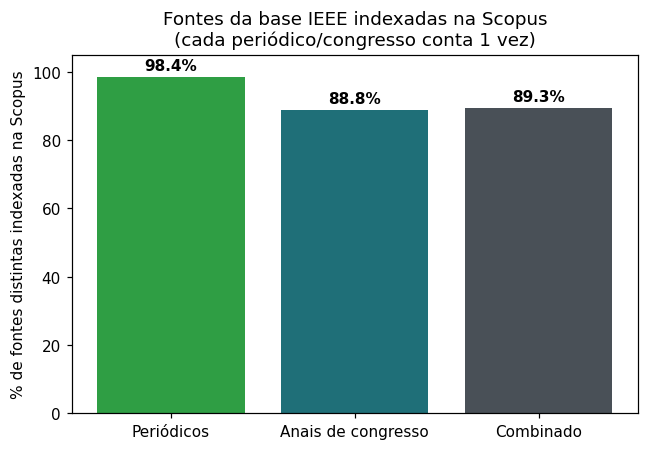

In [9]:
dados_barra = resumo.loc[["Periódicos", "Anais de congresso", "Combinado"]]
fig, ax = plt.subplots(figsize=(6, 4.2))
cores = ["#2f9e44", "#1f6f78", "#495057"]
ax.bar(dados_barra.index, dados_barra["%"], color=cores)
ax.set_ylim(0, 105)
ax.set_ylabel("% de fontes distintas indexadas na Scopus")
ax.set_title("Fontes da base IEEE indexadas na Scopus\n(cada periódico/congresso conta 1 vez)")
for i, v in enumerate(dados_barra["%"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", weight="bold")
plt.tight_layout()
plt.show()

## 8. Fontes não encontradas na lista oficial da Scopus

Lista das fontes distintas não casadas, para conferência manual se necessário. **Sem inferir causa** (não verifiquei porte, alcance ou motivo de cada uma ficar de fora — só reporto o fato de não terem sido encontradas).

In [10]:
nao_indexadas = fontes_unicas[~fontes_unicas["indexado"]].sort_values("ano", ascending=False)
print(f"Total de fontes distintas não encontradas: {len(nao_indexadas)}")
nao_indexadas[["fonte", "tipo_fonte", "ano", "issn", "isbn"]].reset_index(drop=True)

Total de fontes distintas não encontradas: 122


,fonte,tipo_fonte,ano,issn,isbn
0,"2025 17th International Conference on Advanced Technologies, Systems and Services in Telecommuni...",conferencia,2025,2995-0651,979-8-3315-4416-4
1,2025 IEEE 29th International Conference on Intelligent Engineering Systems (INES),conferencia,2025,1543-9259,979-8-3315-9771-9
2,2025 16th International Conference on Logistics and Supply Chain Management (LOGISTIQUA),conferencia,2025,2166-7373,979-8-3315-5312-8
3,2025 IEEE 12th International Conference on Computational Cybernetics and Cyber-Medical Systems (...,conferencia,2025,2689-7768,979-8-3315-0246-1
4,IEEE Transactions on AgriFood Electronics,periodico,2025,2771-9529,NaN
...,...,...,...,...,...
117,Proceedings of the Third International Conference on Information Fusion,conferencia,2000,NaN,2-7257-0000-0
118,IEEE/AFCEA EUROCOMM 2000. Information Systems for Enhanced Public Safety and Security (Cat. No.0...,conferencia,2000,NaN,0-7803-6323-X
119,16th DASC. AIAA/IEEE Digital Avionics Systems Conference. Reflections to the Future. Proceedings,conferencia,1997,NaN,0-7803-4150-3
120,Proceedings of 1st International Conference on Conventional and Knowledge Based Intelligent Elec...,conferencia,1997,NaN,0-7803-3755-7


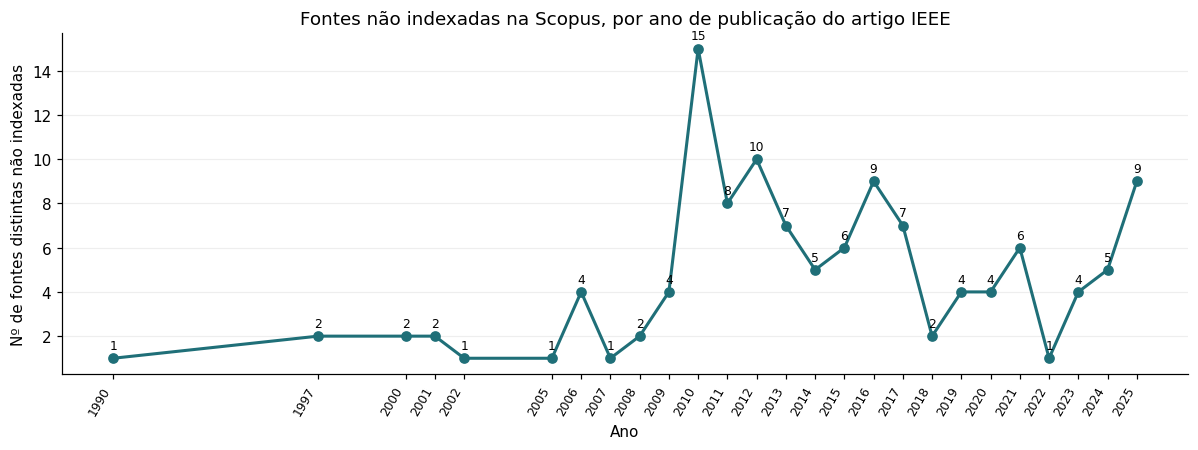

In [11]:
por_ano_nao_idx = pd.to_numeric(nao_indexadas["ano"], errors="coerce").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(por_ano_nao_idx.index.astype(int), por_ano_nao_idx.values, marker="o", color="#1f6f78", linewidth=2)
for x, y in zip(por_ano_nao_idx.index.astype(int), por_ano_nao_idx.values):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
ax.set_title("Fontes não indexadas na Scopus, por ano de publicação do artigo IEEE")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de fontes distintas não indexadas")
ax.set_xticks(por_ano_nao_idx.index.astype(int))
ax.set_xticklabels(por_ano_nao_idx.index.astype(int), rotation=60, ha="right", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#eee")
plt.tight_layout()
plt.show()

## 9. Fora do escopo: livros, capítulos e normas

A Scopus não trata livros/capítulos/normas como periódico nem como anais de congresso — não entram no cálculo da seção 7.

In [12]:
df_ieee[df_ieee["tipo_fonte"] == "livro_norma"]["Document Identifier"].value_counts()

Document Identifier
Packt Publishing eBooks                        23
Wiley Data and Cybersecurity eBook Chapters    18
River eBook Chapters                           12
De Gruyter eBook Chapters                       9
Wiley AI eBook Chapters                         8
Wiley-IEEE Press eBook Chapters                 5
IEEE Standards                                  5
Artech Books                                    1
Name: count, dtype: int64

## 10. Conclusão

**Praticamente 100% dos periódicos distintos e cerca de 88,8% dos congressos distintos onde recuperei artigos na IEEE Xplore são fontes indexadas na Scopus (combinado: 89,3% das fontes). Verificado por casamento de ISSN e ISBN contra a lista oficial de fontes da Elsevier, jul/2026.**

## 11. Exportação — detalhe por fonte

In [13]:
fontes_unicas.to_csv("completude_ieee_scopus_fontes.csv", index=False, encoding="utf-8")
print("Salvo em completude_ieee_scopus_fontes.csv")

Salvo em completude_ieee_scopus_fontes.csv
